**Majid**

In [ ]:
# Cell 1: Install Required Dependencies
# ===============================================

!pip install kagglehub
!pip install opencv-python-headless
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install tensorflow
!pip install tqdm

print(" All dependencies installed successfully!")

 All dependencies installed successfully!


In [ ]:
# Cell 2: Import Libraries and Configuration
# ===============================================

import kagglehub
import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import seaborn as sns
import pandas as pd
import glob
import warnings
import gc
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
CONFIG = {
    'IMG_SIZE': (224, 224),
    'BATCH_SIZE': 16,  # Reduced for Colab
    'EPOCHS': 15,      # Reduced for faster training
    'FINE_TUNE_EPOCHS': 10,
    'LEARNING_RATE': 0.001,
    'FINE_TUNE_LR': 0.0001,
    'TRAIN_SPLIT': 0.7,
    'VAL_SPLIT': 0.15,
    'TEST_SPLIT': 0.15,
    'PATIENCE': 5,
    'DISEASE_THRESHOLD': 0.1,
    'RANDOM_STATE': 42
}

# Paths
PATHS = {
    'BASE_DIR': '/content/tobacco_classification',
    'SOURCE_ROOT': None,
    'MERGED_ROOT': '/content/tobacco_classification/merged_data',
    'FINAL_ROOT': '/content/tobacco_classification/final_data',
    'MODELS_DIR': '/content/tobacco_classification/models',
    'RESULTS_DIR': '/content/tobacco_classification/results'
}

# Create directories
for path in PATHS.values():
    if path and path != PATHS['SOURCE_ROOT']:
        os.makedirs(path, exist_ok=True)

print(" Configuration and directories setup complete!")

 Configuration and directories setup complete!


In [ ]:
# Cell 3: Data Download and Safe File Operations
# ===============================================

def safe_copy_file(src, dst, max_retries=3):
    """Safely copy file with proper resource management"""
    for attempt in range(max_retries):
        try:
            # Ensure destination directory exists
            os.makedirs(os.path.dirname(dst), exist_ok=True)

            # Copy file with explicit resource management
            with open(src, 'rb') as fsrc:
                with open(dst, 'wb') as fdst:
                    shutil.copyfileobj(fsrc, fdst, 65536)  # 64KB chunks
            return True
        except Exception as e:
            if attempt == max_retries - 1:
                print(f" Failed to copy {src}: {e}")
                return False
            continue
    return False

def download_dataset():
    """Download tobacco leaf dataset from KaggleHub"""
    try:
        print(" Downloading tobacco leaf disease dataset...")
        path = kagglehub.dataset_download("chzili/dataset-for-tobacco-leaf-disease-segmentation")
        print(f" Downloaded to: {path}")

        # List contents
        if os.path.exists(path):
            contents = os.listdir(path)
            print(f" Contents: {contents}")
            return path
        else:
            print(" Download path not found")
            return None

    except Exception as e:
        print(f" Error downloading dataset: {e}")
        return None

# Download dataset
source_path = download_dataset()
if source_path:
    PATHS['SOURCE_ROOT'] = source_path
    print(f" Dataset ready at: {source_path}")
else:
    print(" Failed to download dataset")

print(" Data download setup complete!")

100%|██████████| 2.56G/2.56G [00:32<00:00, 85.4MB/s]

Extracting files...


 Downloaded to: /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1
 Contents: ['data1', 'data2']
 Dataset ready at: /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1
 Data download setup complete!


In [ ]:
# Cell 4: Data Processing Functions
# ===============================================

def is_diseased_mask(mask_path, threshold=CONFIG['DISEASE_THRESHOLD']):
    """Determine if a mask indicates disease based on non-black pixel ratio"""
    try:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return False

        non_black = cv2.countNonZero(mask)
        ratio = non_black / (mask.shape[0] * mask.shape[1])
        return ratio > threshold
    except Exception as e:
        return False

def process_dataset_batch(file_list, source_dir, target_healthy, target_diseased, batch_size=100):
    """Process files in batches to avoid memory issues"""
    healthy_count = 0
    diseased_count = 0
    error_count = 0

    for i in range(0, len(file_list), batch_size):
        batch = file_list[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(file_list)-1)//batch_size + 1}")

        for fname in tqdm(batch, desc=f"Batch {i//batch_size + 1}"):
            img_path = os.path.join(source_dir, "imgs", fname)
            mask_path = os.path.join(source_dir, "masks", fname)

            if not os.path.exists(img_path) or not os.path.exists(mask_path):
                continue

            try:
                if is_diseased_mask(mask_path):
                    if safe_copy_file(img_path, os.path.join(target_diseased, fname)):
                        diseased_count += 1
                else:
                    if safe_copy_file(img_path, os.path.join(target_healthy, fname)):
                        healthy_count += 1
            except Exception as e:
                error_count += 1

        # Force garbage collection after each batch
        gc.collect()

    return healthy_count, diseased_count, error_count

def organize_tobacco_data(source_path):
    """Organize tobacco data with safe file handling"""
    print(" Organizing tobacco leaf data...")

    # Create target directories
    healthy_dir = os.path.join(PATHS['MERGED_ROOT'], 'healthy')
    diseased_dir = os.path.join(PATHS['MERGED_ROOT'], 'diseased')
    os.makedirs(healthy_dir, exist_ok=True)
    os.makedirs(diseased_dir, exist_ok=True)

    total_healthy = 0
    total_diseased = 0
    total_errors = 0

    # Look for data directories
    data_dirs = []
    for root, dirs, files in os.walk(source_path):
        if 'imgs' in dirs and 'masks' in dirs:
            data_dirs.append(root)

    print(f"Found {len(data_dirs)} data directories")

    for data_dir in data_dirs:
        imgs_dir = os.path.join(data_dir, "imgs")

        if not os.path.exists(imgs_dir):
            continue

        print(f" Processing {data_dir}...")
        image_files = [f for f in os.listdir(imgs_dir)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not image_files:
            continue

        h_count, d_count, e_count = process_dataset_batch(
            image_files, data_dir, healthy_dir, diseased_dir
        )

        total_healthy += h_count
        total_diseased += d_count
        total_errors += e_count

    print(f" Data organization complete!")
    print(f"    Healthy leaves: {total_healthy}")
    print(f"    Diseased leaves: {total_diseased}")
    print(f"    Errors: {total_errors}")

    return total_healthy, total_diseased

# Execute data organization
if PATHS['SOURCE_ROOT']:
    healthy_count, diseased_count = organize_tobacco_data(PATHS['SOURCE_ROOT'])
else:
    print(" No source data available")

print(" Data processing complete!")

 Organizing tobacco leaf data...
Found 2 data directories
 Processing /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1/data1/data1...
Processing batch 1/20


Batch 1: 100%|██████████| 100/100 [00:00<00:00, 222.79it/s]


Processing batch 2/20


Batch 2: 100%|██████████| 100/100 [00:00<00:00, 220.07it/s]


Processing batch 3/20


...

Processing batch 14/15


Batch 14: 100%|██████████| 100/100 [00:00<00:00, 233.07it/s]


Processing batch 15/15


Batch 15: 100%|██████████| 100/100 [00:00<00:00, 188.87it/s]


 Data organization complete!
    Healthy leaves: 3331
    Diseased leaves: 169
    Errors: 0
 Data processing complete!


In [ ]:
# Cell 5: Image Preprocessing
# ===============================================

def apply_clahe(image):
    """Apply CLAHE for contrast enhancement"""
    try:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    except:
        return image

def preprocess_images_batch(source_dir, target_dir, batch_size=50):
    """Preprocess images in batches to avoid memory issues"""
    if not os.path.exists(source_dir):
        print(f" Source directory not found: {source_dir}")
        return 0, 0

    os.makedirs(target_dir, exist_ok=True)

    image_files = [f for f in os.listdir(source_dir)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print(f" No images found in {source_dir}")
        return 0, 0

    processed_count = 0
    error_count = 0

    for i in range(0, len(image_files), batch_size):
        batch = image_files[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(image_files)-1)//batch_size + 1}")

        for fname in tqdm(batch, desc=f"Preprocessing batch {i//batch_size + 1}"):
            img_path = os.path.join(source_dir, fname)

            try:
                # Read and preprocess image
                img = cv2.imread(img_path)
                if img is None:
                    error_count += 1
                    continue

                # Resize to target size
                img = cv2.resize(img, CONFIG['IMG_SIZE'])

                # Apply contrast enhancement
                img = apply_clahe(img)

                # Save processed image
                save_path = os.path.join(target_dir, fname)
                cv2.imwrite(save_path, img)
                processed_count += 1

            except Exception as e:
                error_count += 1

        # Force garbage collection
        gc.collect()

    print(f" Processed {processed_count} images, {error_count} errors")
    return processed_count, error_count

# Preprocess images for both classes
for cls in ['healthy', 'diseased']:
    source_path = os.path.join(PATHS['MERGED_ROOT'], cls)
    target_path = os.path.join(PATHS['FINAL_ROOT'], cls)

    print(f"\n Preprocessing {cls} images...")
    processed, errors = preprocess_images_batch(source_path, target_path)

print(" Image preprocessing complete!")


 Preprocessing healthy images...
Processing batch 1/67


Preprocessing batch 1: 100%|██████████| 50/50 [00:01<00:00, 25.28it/s]


Processing batch 2/67


Preprocessing batch 2: 100%|██████████| 50/50 [00:01<00:00, 42.92it/s]


Processing batch 3/67


...

Processing batch 3/4


Preprocessing batch 3: 100%|██████████| 50/50 [00:01<00:00, 41.83it/s]


Processing batch 4/4


Preprocessing batch 4: 100%|██████████| 19/19 [00:00<00:00, 34.86it/s]


 Processed 169 images, 0 errors
 Image preprocessing complete!


In [ ]:
# Cell 6: Data Loading and Splitting
# ===============================================

def load_data_paths():
    """Load image paths and labels efficiently"""
    healthy_dir = os.path.join(PATHS['FINAL_ROOT'], 'healthy')
    diseased_dir = os.path.join(PATHS['FINAL_ROOT'], 'diseased')

    healthy_files = []
    diseased_files = []

    # Load healthy files
    if os.path.exists(healthy_dir):
        healthy_files = [os.path.join(healthy_dir, f) for f in os.listdir(healthy_dir)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Load diseased files
    if os.path.exists(diseased_dir):
        diseased_files = [os.path.join(diseased_dir, f) for f in os.listdir(diseased_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Combine paths and labels
    X_paths = np.array(healthy_files + diseased_files)
    y_labels = np.array([0]*len(healthy_files) + [1]*len(diseased_files))

    # Shuffle data
    X_paths, y_labels = shuffle(X_paths, y_labels, random_state=CONFIG['RANDOM_STATE'])

    print(f" Data loaded:")
    print(f"    Total images: {len(X_paths)}")
    print(f"    Healthy: {len(healthy_files)}")
    print(f"    Diseased: {len(diseased_files)}")

    return X_paths, y_labels

def split_data(X_paths, y_labels):
    """Split data into train/val/test sets"""
    if len(X_paths) == 0:
        return None, None, None, None, None, None

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_paths, y_labels,
        test_size=CONFIG['TEST_SPLIT'],
        stratify=y_labels,
        random_state=CONFIG['RANDOM_STATE']
    )

    # Second split: train and validation
    val_size = CONFIG['VAL_SPLIT'] / (1 - CONFIG['TEST_SPLIT'])
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size,
        stratify=y_temp,
        random_state=CONFIG['RANDOM_STATE']
    )

    print(f" Data split:")
    print(f"    Train: {len(X_train)} ({len(X_train)/len(X_paths)*100:.1f}%)")
    print(f"    Val: {len(X_val)} ({len(X_val)/len(X_paths)*100:.1f}%)")
    print(f"    Test: {len(X_test)} ({len(X_test)/len(X_paths)*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test

# Load and split data
X_paths, y_labels = load_data_paths()

if len(X_paths) > 0:
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_paths, y_labels)
    print(" Data loading and splitting complete!")
else:
    print(" No data found for loading")
    X_train = X_val = X_test = y_train = y_val = y_test = None

 Data loaded:
    Total images: 3500
    Healthy: 3331
    Diseased: 169
 Data split:
    Train: 2450 (70.0%)
    Val: 525 (15.0%)
    Test: 525 (15.0%)
 Data loading and splitting complete!


 Creating datasets...
 Datasets created successfully!

 Sample data visualization:


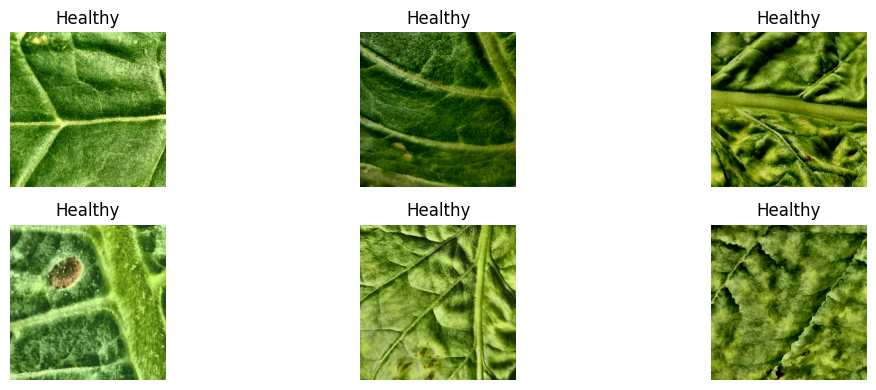

In [ ]:
# Cell 7: Data Generators and Augmentation
# ===============================================

def preprocess_image(path, label, augment=False):
    """Preprocess single image with memory management"""
    try:
        # Read and decode image
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.cast(img, tf.float32)
        img.set_shape([None, None, 3])

        # Resize and normalize
        img = tf.image.resize(img, CONFIG['IMG_SIZE'])
        img = img / 255.0

        # Apply augmentation if specified
        if augment:
            # Random horizontal flip
            img = tf.image.random_flip_left_right(img)
            # Random brightness
            img = tf.image.random_brightness(img, 0.2)
            # Random contrast
            img = tf.image.random_contrast(img, 0.8, 1.2)
            # Random rotation (simplified)
            img = tf.image.rot90(img, tf.random.uniform([], 0, 4, dtype=tf.int32))

        return img, label
    except:
        # Return zero tensor on error
        return tf.zeros([*CONFIG['IMG_SIZE'], 3], dtype=tf.float32), label

def create_dataset(paths, labels, augment=False, batch_size=None):
    """Create TensorFlow dataset with efficient loading"""
    if batch_size is None:
        batch_size = CONFIG['BATCH_SIZE']

    if paths is None or len(paths) == 0:
        return None

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Map preprocessing
    dataset = dataset.map(
        lambda x, y: preprocess_image(x, y, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Shuffle if augmenting (training)
    if augment:
        dataset = dataset.shuffle(min(1000, len(paths)))

    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Create datasets
if X_train is not None:
    print(" Creating datasets...")

    train_dataset = create_dataset(X_train, y_train, augment=True)
    val_dataset = create_dataset(X_val, y_val, augment=False)
    test_dataset = create_dataset(X_test, y_test, augment=False)

    print(" Datasets created successfully!")

    # Visualize a few samples
    print("\n Sample data visualization:")
    plt.figure(figsize=(12, 4))

    for i, (images, labels) in enumerate(train_dataset.take(1)):
        for j in range(min(6, images.shape[0])):
            plt.subplot(2, 3, j+1)
            plt.imshow(images[j])
            plt.title(f"{'Diseased' if labels[j] == 1 else 'Healthy'}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(" No training data available for dataset creation")
    train_dataset = val_dataset = test_dataset = None